# Libraries

In [1]:
!python -m pip install -r requirements.txt
!pip install -q optuna

In [2]:
import os
import shutil
import warnings
import joblib
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

# Data

In [3]:
# Load datasets
train_df = pd.read_csv('data/train_test.csv')
val_df = pd.read_csv('data/validation.csv')
dec_df = pd.read_csv('data/december_chart_inputs.csv')
val_template = pd.read_csv('data/validation_predictions_template.csv')

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("December shape:", dec_df.shape)
train_df.head()

Train shape: (48000, 14)
Validation shape: (12000, 13)
December shape: (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## EDA

In [4]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("--- Train Data Info ---")
train_df.info()

print("\n--- Summary Statistics (Numerical Features) ---")
display(train_df.describe())

print("\n--- Missing Values Check ---")
missing_train = train_df.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else "No missing values found in train_df!")

--- Train Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB

--- Summary Statistics (Numerical Features) ---


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000



--- Missing Values Check ---
weight          300
market_index    374
dtype: int64


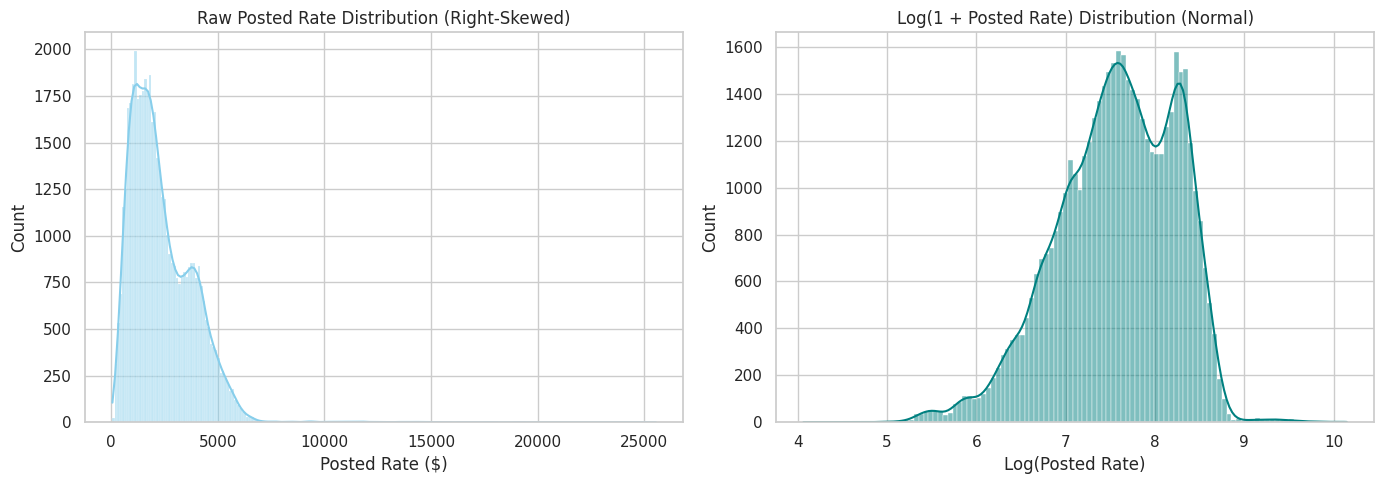


--- Rate Per Mile (RPM) Summary ---
count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rpm, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Target
sns.histplot(train_df["posted_rate"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Raw Posted Rate Distribution (Right-Skewed)")
axes[0].set_xlabel("Posted Rate ($)")

# Log-Transformed Target
sns.histplot(np.log1p(train_df["posted_rate"]), kde=True, ax=axes[1], color="teal")
axes[1].set_title("Log(1 + Posted Rate) Distribution (Normal)")
axes[1].set_xlabel("Log(Posted Rate)")

plt.tight_layout()
plt.show()

# 3. Diagnostic Rate Per Mile (RPM)
train_df["rpm"] = train_df["posted_rate"] / train_df["distance"]
print("\n--- Rate Per Mile (RPM) Summary ---")
print(train_df["rpm"].describe())

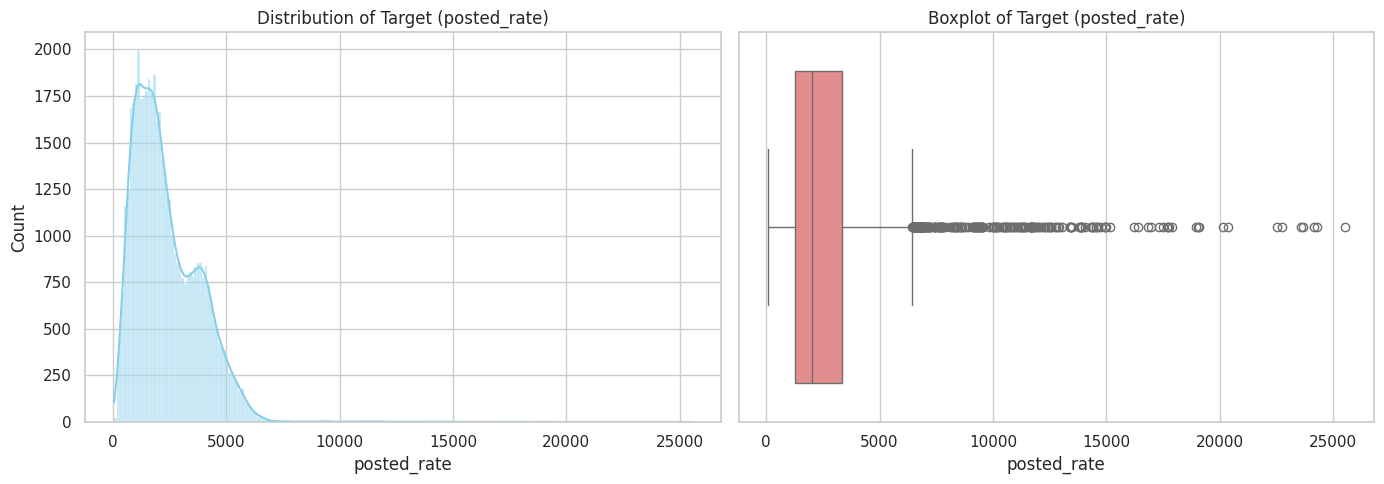

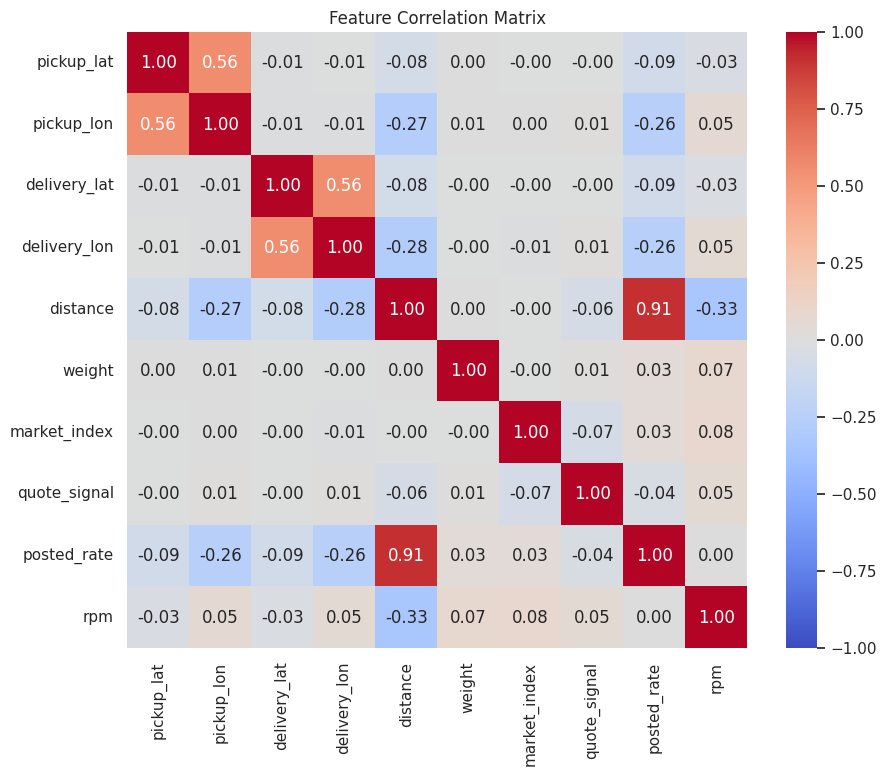

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df['posted_rate'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Target (posted_rate)')

sns.boxplot(x=train_df['posted_rate'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Target (posted_rate)')
plt.tight_layout()
plt.show()

# Feature Correlations
num_cols = train_df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

## Preprocess

In [7]:
def preprocess_df(df):
    df = df.copy()

    # 1. Fix Negative Weights Outliers & Impute Missing Values
    if 'weight' in df.columns:
        df['weight'] = df['weight'].abs()
        df['weight'] = df['weight'].fillna(df['weight'].median())

    # 2. Impute Missing Market Index
    if 'market_index' in df.columns:
        df['market_index'] = df['market_index'].fillna(df['market_index'].median())

    # 3. Categorical Equipment Feature Encoding (Fix 1.A)
    if 'equipment' in df.columns:
        df['is_reefer'] = (df['equipment'] == 'Reefer').astype(int)
        equipment_map = {'Dry Van': 0, 'Reefer': 1, 'Flatbed': 2}
        df['equipment_cat'] = df['equipment'].map(equipment_map).fillna(0).astype(int)

    # 4. Market Pressure Composite Feature (Fix 1.C)
    if 'market_index' in df.columns and 'quote_signal' in df.columns:
        df['market_pressure'] = df['market_index'] * df['quote_signal']

    # 5. Date & Seasonality Features (Fix 1.C)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df['day_of_week'] = df['date'].dt.dayofweek
        df['month'] = df['date'].dt.month

    # 6. Distance Transformations & Interactions
    if 'distance' in df.columns:
        # df['log_distance'] = np.log1p(df['distance'])
        # df['sqrt_distance'] = np.sqrt(df['distance'])

        if 'weight' in df.columns:
            df['weight_per_mile'] = df['weight'] / (df['distance'] + 1.0)

    # 7. Spatial Coordinate Features
    if all(c in df.columns for c in ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon']):
        lat1, lon1, lat2, lon2 = map(
            np.radians,
            [df['pickup_lat'], df['pickup_lon'], df['delivery_lat'], df['delivery_lon']]
        )
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
        df['haversine_dist'] = 2 * 3956 * np.arcsin(np.sqrt(a))

        df['lat_diff'] = (df['delivery_lat'] - df['pickup_lat']).abs()
        df['lon_diff'] = (df['delivery_lon'] - df['pickup_lon']).abs()

    return df

In [8]:
train_clean = preprocess_df(train_df)
val_clean = preprocess_df(val_df)
dec_clean = preprocess_df(dec_df)

feature_cols = [
    # 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'distance',
    # 'log_distance', 'sqrt_distance',
    'weight_per_mile', 'weight', 'market_index', 'quote_signal',
    'market_pressure', 'is_reefer', 'equipment_cat', 'day_of_week',
    'month', 'haversine_dist', 'lat_diff', 'lon_diff'
]

feature_cols = [c for c in feature_cols if c in train_clean.columns]

X = train_clean[feature_cols]
y = np.log1p(train_clean['posted_rate'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model

In [9]:
print("Starting Optuna hyperparameter optimization...")

def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 64),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    val_preds = np.expm1(model.predict(X_val))
    y_val_actual = np.expm1(y_val)

    return np.sqrt(mean_squared_error(y_val_actual, val_preds))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25)

print(f"\nOptimal Hyperparameters Found:")
print(study.best_params)

Starting Optuna hyperparameter optimization...

Optimal Hyperparameters Found:
{'learning_rate': 0.0515029507216956, 'num_leaves': 20, 'max_depth': 7, 'min_child_samples': 68, 'subsample': 0.7952114157448102, 'colsample_bytree': 0.8066628284214752, 'reg_alpha': 2.824226251669023e-08, 'reg_lambda': 1.1575266667177826e-08}


In [10]:
best_params = study.best_params
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'n_estimators': 1000
})

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Train', 'Validation'],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

LGBMRegressor(colsample_bytree=0.8066628284214752,
              learning_rate=0.0515029507216956, max_depth=7, metric='rmse',
              min_child_samples=68, n_estimators=1000, num_leaves=20,
              objective='regression', random_state=42,
              reg_alpha=2.824226251669023e-08,
              reg_lambda=1.1575266667177826e-08, subsample=0.7952114157448102,
              verbosity=-1)

# Evaluation

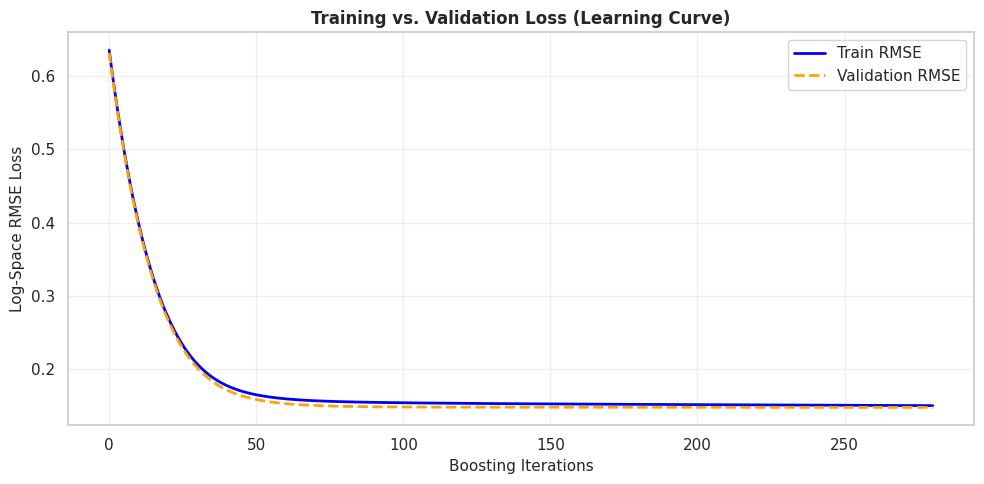

In [11]:
evals_result = final_model.evals_result_

train_rmse_hist = evals_result['Train']['rmse']
val_rmse_hist = evals_result['Validation']['rmse']

plt.figure(figsize=(10, 5))
plt.plot(train_rmse_hist, label='Train RMSE', color='blue', linewidth=2)
plt.plot(val_rmse_hist, label='Validation RMSE', color='orange', linewidth=2, linestyle='--')
plt.title('Training vs. Validation Loss (Learning Curve)', fontsize=12, fontweight='bold')
plt.xlabel('Boosting Iterations', fontsize=11)
plt.ylabel('Log-Space RMSE Loss', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
val_preds = np.expm1(final_model.predict(X_val))
y_val_actual = np.expm1(y_val)

train_preds = np.expm1(final_model.predict(X_train))
y_train_actual = np.expm1(y_train)

train_mae = mean_absolute_error(y_train_actual, train_preds)
val_mae = mean_absolute_error(y_val_actual, val_preds)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val_actual, val_preds))
val_mape = mean_absolute_percentage_error(y_val_actual, val_preds) * 100
val_r2 = r2_score(y_val_actual, val_preds)

print("\n" + "="*40)
print("       FINAL MODEL PERFORMANCE")
print("="*40)
print(f"Train MAE:       ${train_mae:.2f}")
print(f"Validation MAE:  ${val_mae:.2f}")
print(f"Train RMSE:      ${train_rmse:.2f}")
print(f"Validation RMSE: ${val_rmse:.2f}")
print(f"Validation MAPE: {val_mape:.2f}%")
print(f"Validation R²:   {val_r2:.4f}")
print("="*40)


       FINAL MODEL PERFORMANCE
Train MAE:       $102.48
Validation MAE:  $99.99
Train RMSE:      $596.98
Validation RMSE: $527.66
Validation MAPE: 4.72%
Validation R²:   0.8698


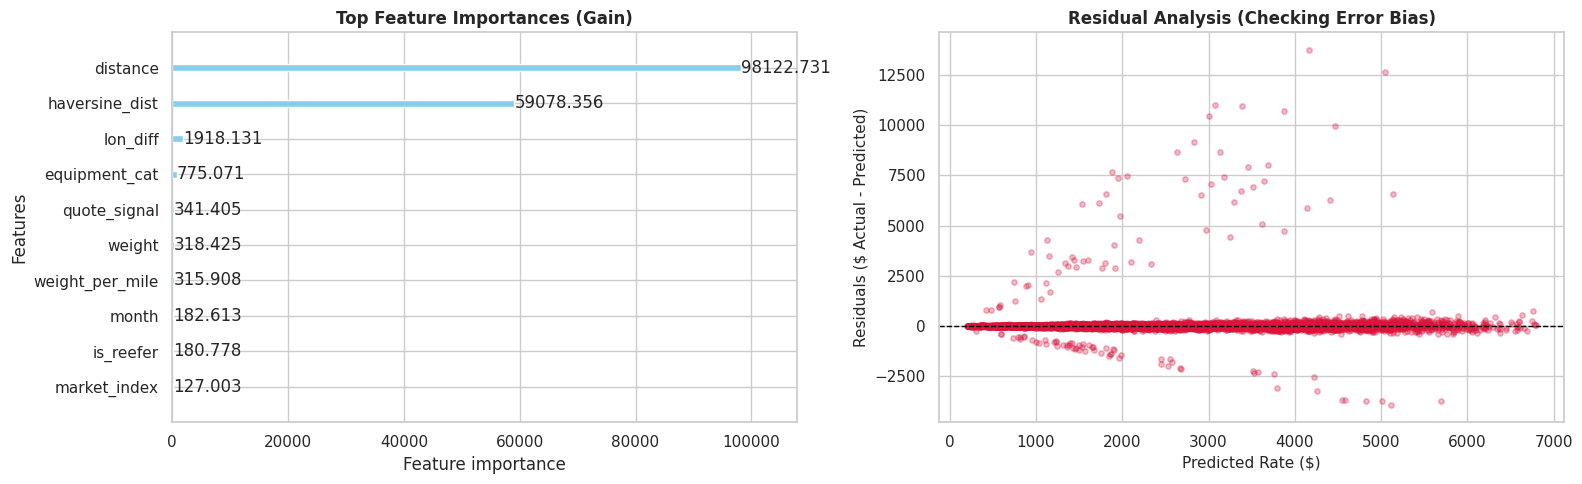

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Feature Importance
lgb.plot_importance(final_model, max_num_features=10, importance_type='gain', ax=axes[0], color='skyblue')
axes[0].set_title('Top Feature Importances (Gain)', fontsize=12, fontweight='bold')

# Plot 2: Residual Analysis
residuals = y_val_actual - val_preds
axes[1].scatter(val_preds, residuals, alpha=0.3, color='crimson', s=15)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Rate ($)', fontsize=11)
axes[1].set_ylabel('Residuals ($ Actual - Predicted)', fontsize=11)
axes[1].set_title('Residual Analysis (Checking Error Bias)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
model_path = 'models/lightgbm_spot_rate_model.pkl'

# Save your fitted LightGBM model object
joblib.dump(final_model, model_path)
print(f"Model successfully saved to {model_path}")

Model successfully saved to models/lightgbm_spot_rate_model.pkl


# Predict

In [15]:
val_df = pd.read_csv('data/validation.csv')

# Apply preprocessing and feature engineering to validation.csv
val_clean = preprocess_df(val_df.copy())

# Handle missing market/spatial defaults if needed
if 'market_index' not in val_clean.columns:
    val_clean['market_index'] = train_clean['market_index'].median()
if 'quote_signal' not in val_clean.columns:
    val_clean['quote_signal'] = train_clean['quote_signal'].median()
val_clean['market_pressure'] = val_clean['market_index'] * val_clean['quote_signal']

spatial_cols = ['haversine_dist', 'lat_diff', 'lon_diff']
for col in spatial_cols:
    if col not in val_clean.columns:
        val_clean[col] = train_clean[col].median()

# Predict log rate and convert back via expm1
val_features = [c for c in feature_cols if c in val_clean.columns]
val_preds = np.expm1(final_model.predict(val_clean[val_features]))

# Export to template format: load_id, predicted_rate
submission_df = pd.DataFrame({
    'load_id': val_df['load_id'],
    'predicted_rate': val_preds
})
submission_df.to_csv('validation_predictions.csv', index=False)
print("Saved 'validation_predictions.csv' (12,000 rows)")

Saved 'validation_predictions.csv' (12,000 rows)


In [16]:
dec_df = pd.read_csv('data/december_chart_inputs.csv')
dec_clean = preprocess_df(dec_df.copy())

if 'market_index' not in dec_clean.columns:
    dec_clean['market_index'] = train_clean['market_index'].median()
if 'quote_signal' not in dec_clean.columns:
    dec_clean['quote_signal'] = train_clean['quote_signal'].median()
dec_clean['market_pressure'] = dec_clean['market_index'] * dec_clean['quote_signal']

for col in spatial_cols:
    if col not in dec_clean.columns:
        dec_clean[col] = train_clean[col].median()

dec_features = [c for c in feature_cols if c in dec_clean.columns]
dec_preds = np.expm1(final_model.predict(dec_clean[dec_features]))

dec_df['predicted_rate'] = dec_preds
dec_df.to_csv('data/december_chart_inputs.csv', index=False)
print("Updated 'data/december_chart_inputs.csv' (31 rows)")

Updated 'data/december_chart_inputs.csv' (31 rows)


In [17]:
cmd = [
    "python", "score.py",
    "--predictions", "validation_predictions.csv",
    "--december-predictions", "data/december_chart_inputs.csv",
    "--output-dir", "scorer_results"
]

result = subprocess.run(cmd, capture_output=True, text=True)
print("\n--- score.py Output ---")
print(result.stdout)

if result.stderr:
    print("--- Errors/Warnings ---")
    print(result.stderr)


--- score.py Output ---
Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.

